# Decision Trees

# 1. Introduction to Decision Trees

Decision Trees are one of the most popular, intuitive, and widely used supervised machine learning algorithms. They are especially powerful because they can handle both classification and regression problems while maintaining a human-friendly, interpretable structure.

At their core, decision trees mimic the way humans make decisions: by asking a sequence of yes/no questions (or more generally, splitting conditions) until a conclusion is reached. For example, if you are trying to decide whether to carry an umbrella:

    First, you may ask: “Is it cloudy?”

    If yes, you ask: “Is rain predicted?”

    If yes, you decide: “Carry umbrella.” Otherwise, “Do not carry umbrella.”

This series of decisions can be represented as a tree, with internal nodes representing questions (splits), branches representing possible answers, and leaves representing the final decision or outcome.

# 2. Structure of a Decision Tree

A decision tree consists of the following components:

1. Root Node

    The topmost node in the tree.

    Represents the first question/split based on the most significant feature.


2. Decision Nodes (Internal Nodes)

    Points where the dataset is split based on feature values.

    Each node corresponds to a test on a particular attribute.


3. Branches (Edges)

    The outcomes of a decision at a node.

    Each branch leads to another node or a leaf.


4. Leaf Nodes (Terminal Nodes)

    Represent the final output or decision.

    In classification, a leaf corresponds to a class label.

    In regression, a leaf corresponds to a predicted continuous value.

# 3. Types of Decision Trees

Decision trees can be categorized in different ways:

    Based on Task:

        Classification Trees → Used when the target variable is categorical (e.g., predicting “Yes/No”, “Spam/Not Spam”).

        Regression Trees → Used when the target variable is continuous (e.g., predicting house price).

    Based on Splitting Criteria:

        ID3 (Iterative Dichotomiser 3)

        C4.5 / C5.0 (Successors of ID3)

    CART (Classification and Regression Tree, widely used in scikit-learn)
    
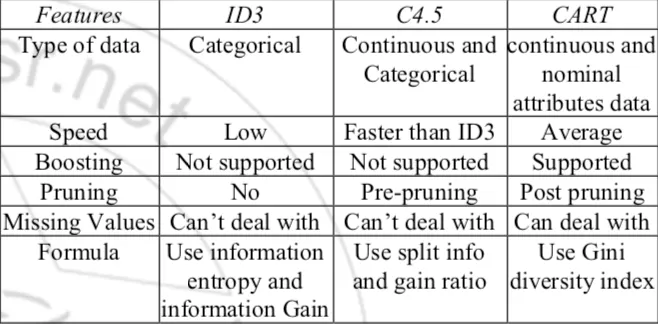

# 4. Intuition Behind Decision Trees

    The main idea is to split the dataset into subsets that are more “pure” with respect to the target variable. A pure subset is one in which most of the instances belong to a single class (in classification), or where values are close to each other (in regression).

    The tree grows by recursively splitting the dataset based on the feature that provides the maximum reduction in impurity (or equivalently, maximum information gain).

# 5. Mathematical Foundations of Splitting

Decision trees use different metrics to decide the “best split.”

    # 5.1 Entropy and Information Gain (used in ID3)

    -> Entropy measures the impurity of a dataset.
        Formula:
                          
                          c
            Entropy(S)= − ∑ ​ pi ​ log2 ​ (pi)
                         i=1
                         
        where 𝑝𝑖 is the proportion of class 𝑖.
    
    -> Information Gain (IG) measures the reduction in entropy after a split.
    
       𝐼𝐺(𝑆,𝐴) = 𝐸𝑛𝑡𝑟𝑜𝑝𝑦(𝑆) −    ∑       (|𝑆𝑣|/|𝑆|)Entropy(Sv)
                             𝑣∈𝑉𝑎𝑙𝑢𝑒𝑠(𝐴)
        

    -> The attribute with the highest IG is chosen for the split.
    
    
    5.2 Gini Index (used in CART)
                                              𝑐
        A measure of impurity: 𝐺𝑖𝑛𝑖(𝑆) = 1 −  ∑  𝑝𝑖**2
                                             𝑖=1

    -> A pure node has Gini = 0.
    -> CART chooses the feature split that minimizes the weighted Gini index.
    
    5.3 Variance Reduction (for Regression Trees)

    For regression problems, variance of the target is used as impurity.

    The split that leads to the maximum reduction in variance is chosen.

# 6. Building a Decision Tree (Step-by-Step)

Start with the full dataset at the root node.

Calculate the impurity (entropy, Gini, or variance).

For each feature, calculate the impurity of subsets resulting from possible splits.

Select the split with the highest information gain (or lowest Gini/variance).

Create child nodes based on this split.

Repeat recursively until stopping conditions are met:

    Node is pure (all samples belong to one class).

    No features left.

    Maximum depth reached.

    Minimum number of samples at node reached.

# 7. Example of Decision Tree (Classification)

Suppose we want to predict whether a passenger survived the Titanic disaster using features like sex, age, class.

    Root node: Check if sex == female

        If yes → high probability of survival.

        If no → check class.

            If class = 1st → higher chance.

            If class = 3rd → lower chance.

This simple tree can already capture strong predictive patterns in the dataset.

# 8. Overfitting and Underfitting

Decision trees are prone to overfitting because they can grow very deep and memorize training data.

    Overfitting → Tree is too complex, performs well on training data but poorly on unseen data.

    Underfitting → Tree is too shallow, fails to capture patterns.

Solution: Use hyperparameter tuning and pruning.

# 9. Tree Pruning

Pruning reduces the size of the tree to improve generalization.

Pre-pruning (Early Stopping):

    Limit tree depth.

        Minimum samples required to split a node.

        Minimum samples required at a leaf.

    Post-pruning:

        Grow a full tree and then remove branches that provide little predictive power.

# 10. Advantages of Decision Trees

Easy to understand and interpret.

Handles both numerical and categorical data.

Requires little data preprocessing (no scaling/normalization).

Can capture non-linear relationships.

Works well for feature selection.

# 11. Limitations of Decision Trees

High risk of overfitting.

Instability: small changes in data can change the structure of the tree.

Greedy nature: locally optimal splits may not yield the best global solution.

Biased towards features with more levels.

Less accurate compared to ensemble methods.

# 12. Improvements Over Decision Trees

To overcome limitations, ensemble methods are widely used:

    Random Forest: An ensemble of decision trees using bagging. Reduces overfitting.

    Gradient Boosted Trees (XGBoost, LightGBM, CatBoost): Sequentially build trees to correct errors of previous ones. Very powerful for structured/tabular data.

# 13. Applications of Decision Trees

Medical diagnosis (predicting diseases).

Finance (credit scoring, risk analysis).

Marketing (customer segmentation).

Natural language processing (spam detection).

Operations research (decision support systems).

# 14. Interpretability of Decision Trees

One of the strongest advantages is interpretability:

    We can visualize the tree.

    Each path can be interpreted as a clear set of rules:

        “If age < 18 AND class = 1st → predict survived.”

    Useful for domains where explainability is critical.

# 15. Practical Considerations

Always preprocess missing values before training.

Encode categorical features properly (one-hot or label encoding).

Use cross-validation to select optimal tree depth and splitting parameters.

Combine with ensemble techniques for best performance.

# 16. Summary

Decision trees are:

Intuitive, interpretable models.

Useful for both classification and regression.

Built using splitting criteria like entropy, Gini index, or variance reduction.

Prone to overfitting, but can be controlled with pruning.

Often used as base learners in more powerful ensemble methods like Random Forests and Gradient Boosting.

# Code Base Development


# Step 1: Import Libraries


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Step 2: Load the Dataset

In [4]:
# import pandas as pd
# import io
# from google.colab import files

# # Step 1: Upload the file
# uploaded = files.upload()

# # Step 2: Get the uploaded filename (key of the dictionary)
# filename = list(uploaded.keys())[0]  # I am using here 'train_and_test2 (1).csv'

# # Step 3: Read the CSV file from the uploaded content
# df = pd.read_csv(io.BytesIO(uploaded[filename]))

# # Step 4: Display the first few rows
# df.head()


df = pd.read_csv("C:\\Users\\haida\\Downloads\\titanic.csv")

In [5]:
# 3. Drop Irrelevant or Dummy Columns
drop_cols = [col for col in df.columns if 'zero' in col.lower()]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [6]:
# 4. Rename Misspelled Columns (2urvived ➝ Survived)
df.rename(columns={'2urvived': 'Survived'}, inplace=True)
df

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0


# Step 3: Explore the Data

In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB
None
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


# Step 4: Handle Missing Values

In [8]:
# age → fill with median

# embarked → fill with mode

# fare → fill with median


df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)


C:\Users\haida\AppData\Local\Temp\ipykernel_6356\4159439899.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\haida\AppData\Local\Temp\ipykernel_6356\4159439899.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

0         7.2500
1        71.2833
2         7.9250
3        53.1000
4         8.0500
          ...   
1304      8.0500
1305    108.9000
1306      7.2500
1307      8.0500
1308     22.3583
Name: Fare, Length: 1309, dtype: float64

In [9]:
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


# Step 5: Encode Categorical Variables

In [10]:
# Convert non-numeric features (like sex, embarked) into numbers.

label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

# Step 6: Define Features (X) and Target (y)

In [11]:
df.rename(columns={'2urvived': 'Survived'}, inplace=True)

In [12]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# Step 7: Split Data into Train & Test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train Decision Tree Classifier

In [14]:
model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# Step 9: Make Predictions

In [15]:
y_pred = model.predict(X_test)

# Step 10: Evaluate the Model

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8549618320610687

Confusion Matrix:
 [[172  17]
 [ 21  52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90       189
           1       0.75      0.71      0.73        73

    accuracy                           0.85       262
   macro avg       0.82      0.81      0.82       262
weighted avg       0.85      0.85      0.85       262



# Step 11: Visualize the Tree

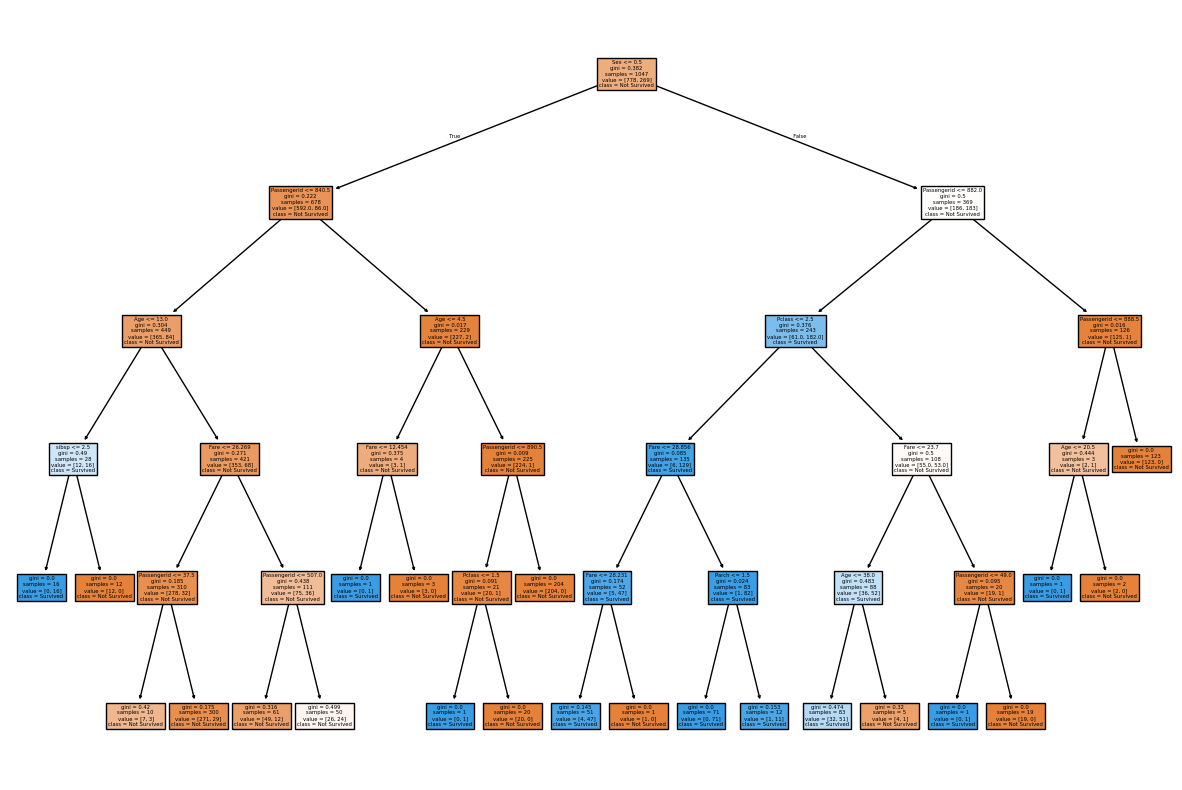

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
tree.plot_tree(model, feature_names=X.columns, class_names=["Not Survived","Survived"], filled=True)
plt.show()